In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [30]:
from google.colab import files
uploaded=files.upload()

Saving placement.csv to placement (1).csv


In [31]:
df=pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

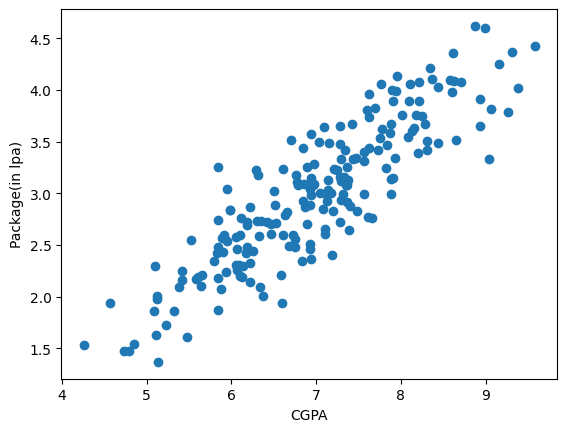

In [32]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [33]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]


In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [35]:
X_train.shape

(160, 1)

In [36]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [37]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

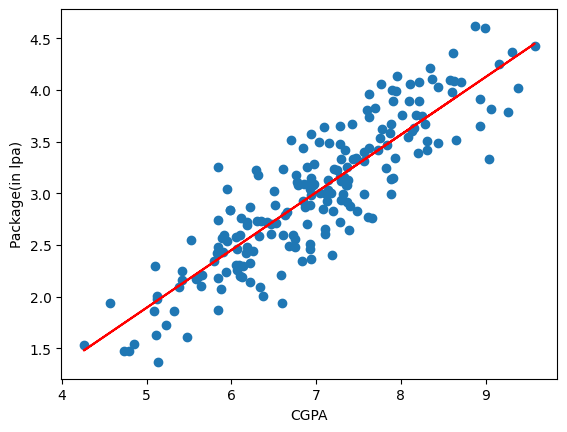

In [38]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [39]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

In [40]:
lr.predict(X_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [41]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [42]:
print('MAE',mean_absolute_error(y_test,lr.predict(X_test))) #Average of |actual - predicted|
print('MSE',mean_squared_error(y_test,lr.predict(X_test))) #Average of (actual - predicted)²

MAE 0.2884710931878175
MSE 0.12129235313495527


In [43]:
print("RMSE",np.sqrt(mean_squared_error(y_test,lr.predict(X_test)))) #√MSE

RMSE 0.34827051717731616


In [44]:
#r2 score
print('r2 scorw',r2_score(y_test,lr.predict(X_test)))  #Overall model performance summary

r2 scorw 0.780730147510384


In [45]:
#adjusted R2
X_test.shape

(40, 1)

In [46]:
1- (1-r2_score(y_test,lr.predict(X_test))) * (len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7749598882343415

check by adding irrelevant feature

In [47]:
new_df1=df.copy()
new_df1['random_feature'] = np.random.random(200)
new_df1.head()

,cgpa,package,random_feature
0,6.89,3.26,0.446078
1,5.12,1.98,0.006987
2,7.82,3.25,0.038640
3,7.42,3.67,0.821966
4,6.94,3.57,0.933779


In [48]:
new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.446078,3.26
1,5.12,0.006987,1.98
2,7.82,0.038640,3.25
3,7.42,0.821966,3.67
4,6.94,0.933779,3.57


Text(0, 0.5, 'Package(in lpa)')

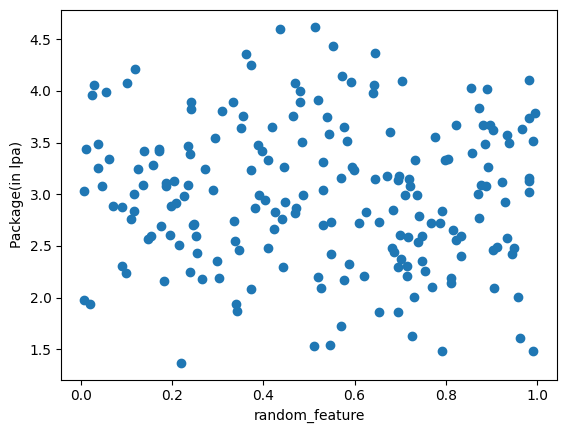

In [49]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [50]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
lr = LinearRegression()

In [53]:
lr.fit(X_train,y_train)

LinearRegression()

In [54]:
y_pred = lr.predict(X_test)

In [55]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)   #Standard $R^2$ fraud karta hai—yeh faaltu features par bhi artificial increment dikha deta hai.

R2 score 0.7875132683553066


In [56]:
1 - ((1-r2)*(40-1)/(40-1-2))
# Adjusted $R^2$ bilkul sahi pakadti hai: agar feature useless hai, toh penalty apply karke score ko kam kar deti hai.

0.776027499077215

In [57]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [58]:
new_df2.sample(5)


,cgpa,iq,package
16,6.84,2.65,2.35
41,6.89,1.60,2.70
4,6.94,4.67,3.57
150,6.30,2.83,2.73
199,6.22,2.33,2.33


Text(0, 0.5, 'Package(in lpa)')

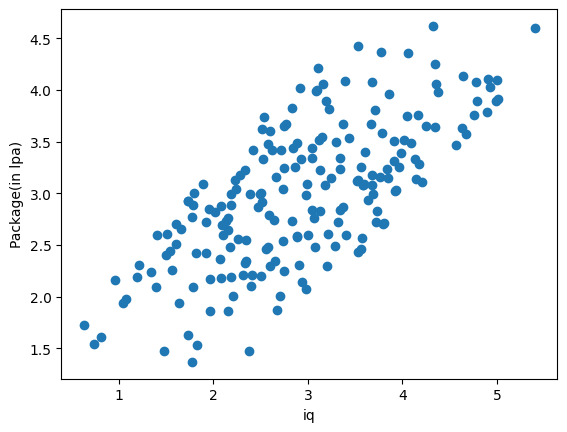

In [59]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [60]:

X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [62]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [63]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7955028567249687


In [64]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7844489570884805